In [1]:
from datetime import datetime
import pandas as pd

def add_milestone(ax, project_start, date, row, label,
                  epic_id=None,  # ✅ NEW
                  color="#d62728", marker_size=80,
                  label_offset_days=2, label_va="center", label_ha="left",
                  fontdict=None, zorder=6):

    def build_ado_url(epic_id):
        if epic_id is None or pd.isna(epic_id):
            return None
        return f"https://dev.azure.com/bc-icm/FODIG/_workitems/edit/{int(epic_id)}"

    # Parse date
    if isinstance(date, str):
        dt = pd.to_datetime(date).to_pydatetime()
    elif isinstance(date, pd.Timestamp):
        dt = date.to_pydatetime()
    elif isinstance(date, datetime):
        dt = date
    else:
        raise TypeError("date must be datetime, pandas.Timestamp, or str")

    x_days = (dt - project_start).days
    url = build_ado_url(epic_id)

    # ✅ Draw diamond marker
    scatter = ax.scatter(
        [x_days], [row],
        marker='D',
        s=marker_size,
        color=color,
        edgecolors='white',
        linewidths=1.0,
        zorder=zorder
    )

    # ✅ Attach link to marker (works in Acrobat/browser, sometimes Preview)
    if url:
        scatter.set_url(url)

    # ✅ Label (this is the MOST reliable clickable element in Preview)
    if fontdict is None:
        fontdict = {'size': 9, 'color': color}

    text_obj = ax.text(
        x_days + label_offset_days, row,
        label,
        va=label_va, ha=label_ha,
        fontdict=fontdict,
        zorder=zorder
    )

    # ✅ Attach link to label (reliable everywhere, including macOS Preview)
    if url:
        text_obj.set_url(url)

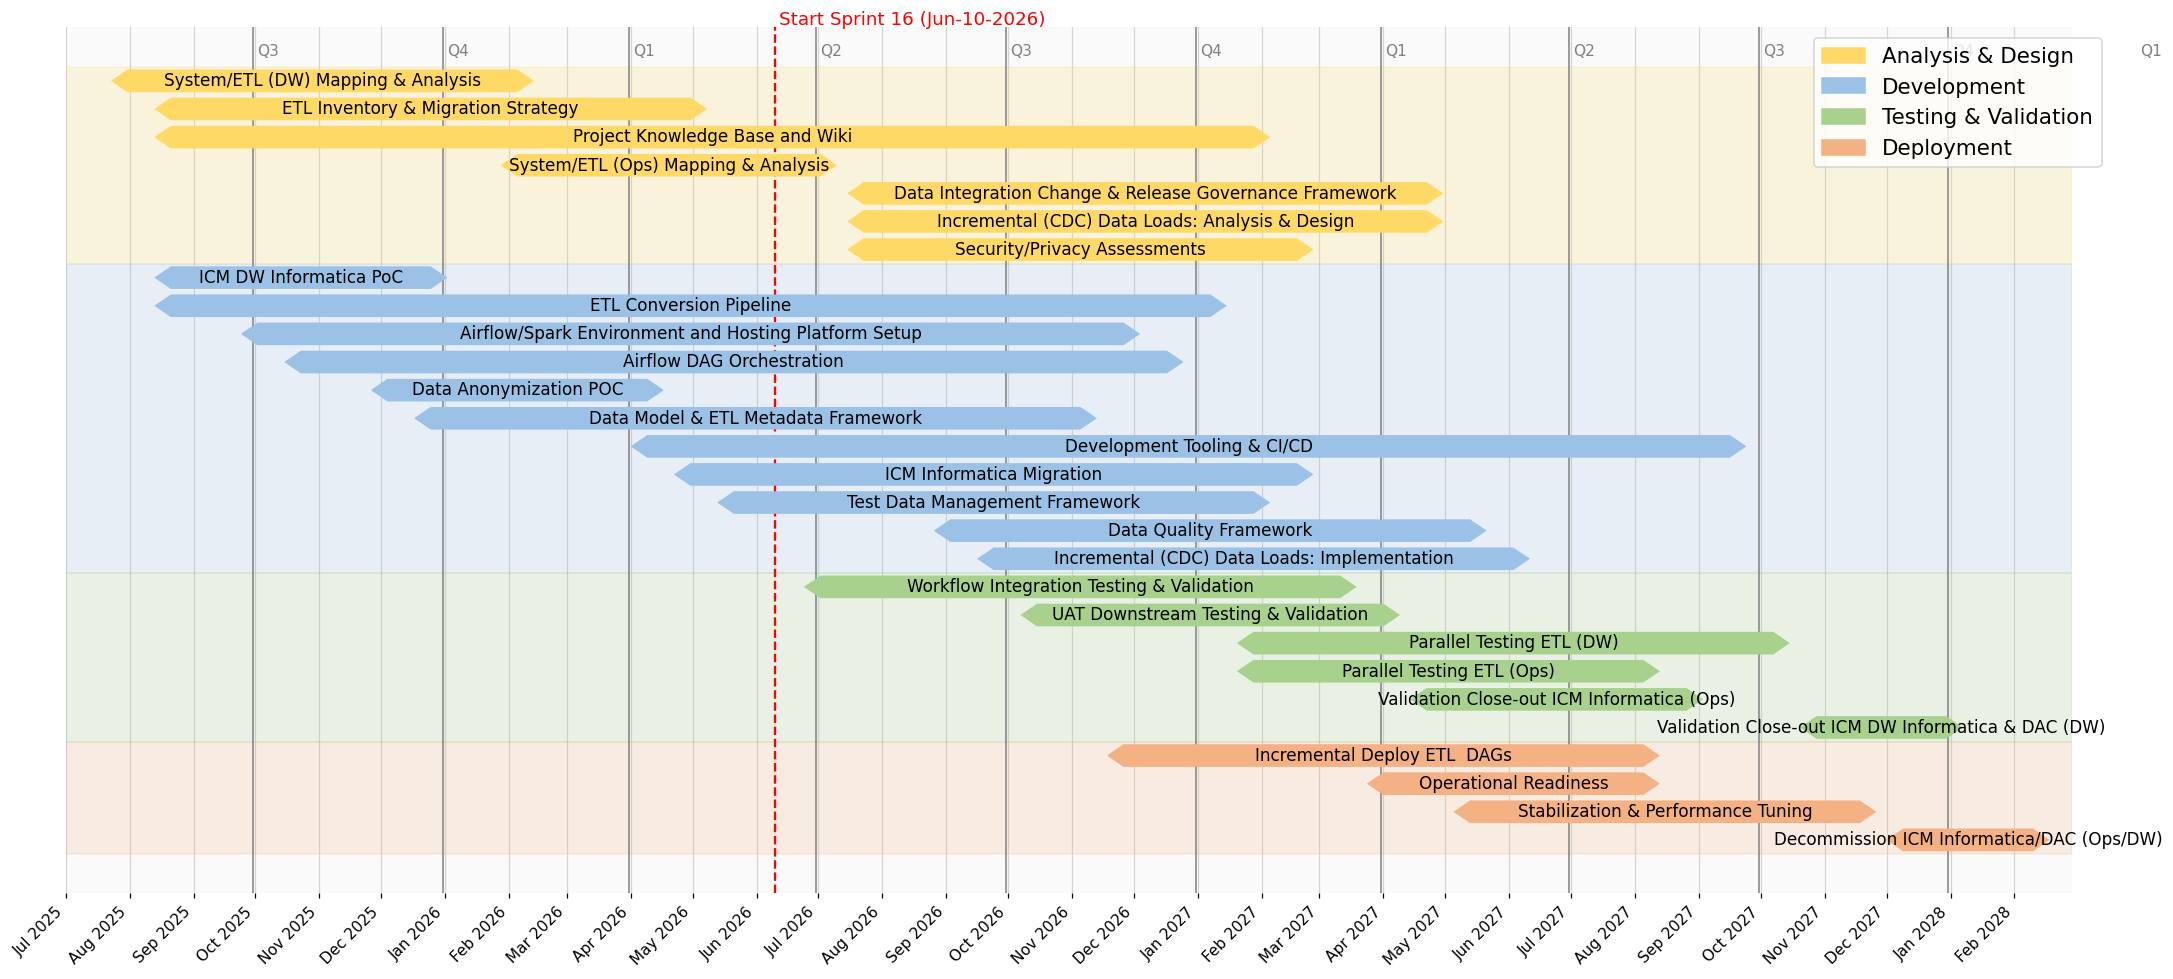

In [2]:

# =========================
# Gantt Timeline (Month/Year X-axis) — minimal CSV inputs
# =========================
# - Reads csv (only: task,phase,start_sprint,sprints)
# - Computes start_date, end_date, start_offset_days, duration_days from PROJECT_START + 3-week sprints
# - Month/Year ticks on X-axis (Aug 2025, Sep 2025, ...)
# - phase color bands, outward tapered bars, labels on bars, hidden Y-axis, today marker

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from datetime import datetime
from calendar import month_abbr
from matplotlib.patches import Patch, Polygon as MplPolygon

# --------- Safe DPI + inline rendering ---------
mpl.rcParams['figure.dpi']  = 110
mpl.rcParams['savefig.dpi'] = 110

# --------- Configuration ---------

# phase order (top to bottom)
phase_order = ["Analysis & Design", "Development", "Testing & Validation", "Deployment"]

# phase colors (consistent with the Excel file)
team_colors = {
    "Analysis & Design": "#FFD966",     # light orange
    "Development": "#9BC2E6",           # light blue
    "Testing & Validation": "#A9D18E",  # light green
    "Deployment": "#F4B183"             # peach
}

# Read and normalize column names
csv_path = "/Users/spencerrose/Workspace/Notebooks/cridir-project-timeline/CriDIR_Project_Roadmap.csv" 
df = pd.read_csv(csv_path)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

PROJECT_START = datetime(2025, 7, 30) # Sprint 1 anchor (your start date)
CURRENT_DATE = datetime(2026, 6, 10) 
SPRINT_DAYS   = 21                    # 3-week sprints

# Bar label styling
TEXT_COLOR_INSIDE  = "black"
TEXT_COLOR_OUTSIDE = "black"
MIN_INSIDE_WIDTH   = 40  # days; if bar shorter than this, place the label outside

# --------- Helpers ---------
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Lowercase and normalize column names; remove spaces and parentheses."""
    df = df.copy()
    df.columns = [c.strip().lower()
                    .replace(" ", "_")
                    .replace("(", "")
                    .replace(")", "")
                  for c in df.columns]
    return df

def sprint_start_dt(sprint_num: int) -> datetime:
    """Return the datetime for the start of a given sprint number (1-based)."""
    return PROJECT_START + pd.Timedelta(days=(int(sprint_num)-1) * SPRINT_DAYS)

def draw_tapered_bar(ax, y, left, width, height=0.8, cap=8, color="#9BC2E6", alpha=1.0, zorder=2, taper="outward"):
    """
    Draw a horizontal bar with tapered ends.
    - taper='outward' points beyond ends; 'inward' points inside ends
    """
    if width is None or width <= 0: return None
    cap = max(0.0, cap) if taper == "outward" else min(cap, width / 2.0)
    hh = height / 2.0
    right = left + width
    if taper == "outward":
        pts = [(left - cap, y), (left, y - hh), (right, y - hh),
               (right + cap, y), (right, y + hh), (left, y + hh)]
    else:
        pts = [(left, y - hh), (left + cap, y), (left, y + hh),
               (right, y + hh), (right - cap, y), (right, y - hh)]
    patch = MplPolygon(pts, closed=True, facecolor=color, edgecolor='none', alpha=alpha, zorder=zorder)
    ax.add_patch(patch)
    return patch

def build_month_ticks(start_dt: datetime, end_dt: datetime):
    """Return (xticks_in_days, xticklabels) for Month/Year between start_dt and end_dt."""
    ticks = []
    labels = []
    year, month = start_dt.year, start_dt.month
    cur = datetime(year, month, 1)
    # generate month starts until end_dt month inclusive
    while cur <= end_dt:
        days_from_start = (cur - start_dt).days
        ticks.append(days_from_start)
        labels.append(f"{month_abbr[cur.month]} {cur.year}")  # e.g., Aug 2025
        # increment month
        next_month = cur.month + 1
        next_year  = cur.year + (1 if next_month == 13 else 0)
        next_month = 1 if next_month == 13 else next_month
        cur = datetime(next_year, next_month, 1)
    return ticks, labels

def build_ado_url(epic_id):
    if pd.isna(epic_id):
        return None
    return f"https://dev.azure.com/bc-icm/FODIG/_workitems/edit/{int(epic_id)}"
    
# --------- Load minimal CSV and compute derived fields ---------
df = pd.read_csv(csv_path)
df = normalize_columns(df)

# Expect minimal columns:
required = {"epic_id", "task", "phase", "start_sprint", "sprints"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"CSV is missing required columns: {missing}")

# Compute derived fields from start_sprint & sprints
df["start_sprint"] = df["start_sprint"].astype(int)
df["sprints"]      = df["sprints"].astype(int)

# Start date, end date
df["start_date"] = df["start_sprint"].apply(lambda s: sprint_start_dt(s))
df["duration_days"] = df["sprints"] * SPRINT_DAYS
df["end_date"] = df["start_date"] + pd.to_timedelta(df["duration_days"] - 1, unit="D")

# Offsets (days from project start)
df["start_offset_days"] = (df["start_date"] - PROJECT_START).dt.days

# Completion (optional): default to full duration unless you add a column
if "completion_days" not in df.columns:
    df["completion_days"] = df["duration_days"]
else:
    df["completion_days"] = df["completion_days"].clip(lower=0, upper=df["duration_days"])

# Sort by phase order then start_date for visual clarity
phase_rank = {phase: i for i, phase in enumerate(phase_order)}
df["phase_rank"] = df["phase"].map(phase_rank).fillna(999)
df = df.sort_values(by=["phase_rank", "start_date"]).reset_index(drop=True)

# Assign integer row positions (y)
df["ypos"] = range(len(df))

# Compute plot window (days from PROJECT_START)
project_end = df["end_date"].max().to_pydatetime()
max_day = (project_end - PROJECT_START).days + 21  # pad one sprint

# Build month/year ticks & labels
xticks, xticklabels = build_month_ticks(PROJECT_START, project_end)

# --------- Plot ---------
fig, ax = plt.subplots(figsize=(20, 9), dpi=110)
ax.set_facecolor("#FAFAFA")
ax.set_axisbelow(True)

# Clamp x-axis to the computed window
ax.set_xlim(0, max_day)

# phase bands
patches = [Patch(color=team_colors[l], label=l) for l in phase_order]
band_alpha = 0.20
for phase in phase_order:
    phase_rows = df[df["phase"] == phase]
    if phase_rows.empty: continue
    y_min = phase_rows["ypos"].min() - 0.5
    y_max = phase_rows["ypos"].max() + 0.5
    ax.axhspan(ymin=y_min, ymax=y_max, color=team_colors[phase], alpha=band_alpha, zorder=1)

# Bars + labels (outward tapered)
# for _, row in df.iterrows():
#     ypos = float(row["ypos"])
#     left = float(row["start_offset_days"]) + 1
#     planned_w = float(row["duration_days"])
#     comp_w = float(row["completion_days"])
#     phase_color = team_colors.get(row["phase"], "#999999")
#     task_name = row["task"]

#     # Planned bar
#     draw_tapered_bar(ax, y=ypos, left=left, width=planned_w,
#                      height=0.8, cap=8, color=phase_color, alpha=0.40, zorder=2, taper="outward")
#     # Completed bar
#     if comp_w and comp_w > 0:
#         draw_tapered_bar(ax, y=ypos, left=left, width=comp_w,
#                          height=0.8, cap=8, color=phase_color, alpha=1.0, zorder=3, taper="outward")

#     # Label on/near the bar
#     width_for_label = comp_w if comp_w and comp_w > 0 else planned_w
#     if width_for_label >= MIN_INSIDE_WIDTH:
#         ax.text(left + width_for_label / 2, ypos, task_name,
#                 va="center", ha="center", color=TEXT_COLOR_INSIDE, fontsize=11, zorder=4)
#     else:
#         ax.text(left + width_for_label + 2, ypos, task_name,
#                 va="center", ha="left", color=TEXT_COLOR_OUTSIDE, fontsize=11, zorder=4)

from matplotlib.patches import Rectangle  # ✅ add at top of file

for _, row in df.iterrows():
    ypos = float(row["ypos"])
    left = float(row["start_offset_days"]) + 1
    planned_w = float(row["duration_days"])
    comp_w = float(row["completion_days"])
    phase_color = team_colors.get(row["phase"], "#999999")
    task_name = row["task"]

    epic_id = row.get("epic_id")
    url = build_ado_url(epic_id)

    # Planned bar (visual)
    planned_patch = draw_tapered_bar(
        ax, y=ypos, left=left, width=planned_w,
        height=0.8, cap=8, color=phase_color,
        alpha=0.40, zorder=2, taper="outward"
    )

    # Completed bar (visual)
    if comp_w and comp_w > 0:
        completed_patch = draw_tapered_bar(
            ax, y=ypos, left=left, width=comp_w,
            height=0.8, cap=8, color=phase_color,
            alpha=1.0, zorder=3, taper="outward"
        )

    # ✅ ✅ ADD: clickable overlay rectangle (Preview-friendly!)
    if url:
        overlay_width = planned_w
        rect = Rectangle(
            (left, ypos - 0.4),
            overlay_width,
            0.8,
            facecolor="none",
            edgecolor="none",
            zorder=5
        )
        rect.set_url(url)
        ax.add_patch(rect)

    # Label (existing logic, now clickable)
    width_for_label = comp_w if comp_w and comp_w > 0 else planned_w

    if width_for_label >= MIN_INSIDE_WIDTH:
        text_obj = ax.text(
            left + width_for_label / 2, ypos, task_name,
            va="center", ha="center",
            color=TEXT_COLOR_INSIDE, fontsize=11, zorder=6
        )
    else:
        text_obj = ax.text(
            left + width_for_label + 2, ypos, task_name,
            va="center", ha="left",
            color=TEXT_COLOR_OUTSIDE, fontsize=11, zorder=6
        )

    # ✅ ✅ ADD: clickable text (this is the key for macOS Preview)
    if url:
        text_obj.set_url(url)
        
# Axis/legend
# Hide Y-axis ticks/labels for clean look
ax.set_yticks([]); ax.set_yticklabels([]); ax.yaxis.set_tick_params(length=0)
for side in ['left','right','top','bottom']: ax.spines[side].set_visible(False)

# Month/Year ticks on X-axis
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=45, ha='right', fontsize=10)
ax.set_xlabel("")
ax.set_title("", fontsize=16)
ax.xaxis.grid(True, alpha=0.5)
ax.invert_yaxis()  # earliest tasks at the top

# Today marker
current_x = (CURRENT_DATE - PROJECT_START).days
ax.axvline(x=current_x, color='r', linestyle='dashed', linewidth=1.5)
ax.text(x=current_x + 2, y=-2.0, s='Start Sprint 16 (' + CURRENT_DATE.strftime('%b-%d-%Y') + ')', color='r', fontsize=12)


# Quarterly markers
quarter_dates = [
    datetime(2025, 9, 30), 
    datetime(2025, 12, 31), 
    datetime(2026, 3, 31), 
    datetime(2026, 6, 30), 
    datetime(2026, 9, 30), 
    datetime(2026, 12, 31),
    datetime(2027, 3, 31), 
    datetime(2027, 6, 30), 
    datetime(2027, 9, 30), 
    datetime(2027, 12, 31),
    datetime(2028, 3, 31)
]
quarter_labels = ['Q3', 'Q4', 'Q1', 'Q2', 'Q3', 'Q4', 'Q1', 'Q2', 'Q3', 'Q4', 'Q1', 'Q2', 'Q3', 'Q4']
for i, quarter_date in enumerate(quarter_dates):
    x = (quarter_date - PROJECT_START).days
    ax.axvline(x, color='grey', linestyle='solid', linewidth=1.0)
    ax.text(x + 2, y=-0.9, s=quarter_labels[i], color='grey', fontsize=10)

# Legend
ax.legend(
    handles=patches, 
    loc="upper right", 
    bbox_to_anchor=(1.02, 1), 
    frameon=True, 
    fontsize=14
)

plt.tight_layout()


In [3]:

# Make sure layout has settled
plt.tight_layout()

PDF_PATH = "cridir-timeline-linked-2026.pdf"

# Save as vector PDF. `bbox_inches="tight"` expands the canvas to include
# anything outside the axes (e.g., a legend in the right margin).
fig.savefig(
    PDF_PATH,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    metadata={
        "Title": "CriDIR Timeline",
        "Author": "SDPR ISD",
        "Subject": "Project timeline Gantt",
    }
)

print(f"Saved PDF → {PDF_PATH}")


Saved PDF → cridir-timeline-linked-2026.pdf


<Figure size 704x528 with 0 Axes>